<a href="https://colab.research.google.com/github/Laere11/Laere11/blob/Batteries/EasyOCR_imagedata_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary packages (if not already installed)
!pip install easyocr opencv-python-headless pandas

import easyocr
import cv2
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Optional: Function to display an image (for debugging)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Initialize EasyOCR Reader for English
reader = easyocr.Reader(['en'])

# Function to extract text using EasyOCR
def extract_text_easyocr(image):
    results = reader.readtext(image)
    # Combine detected text pieces into a single string.
    text = " ".join([res[1] for res in results])
    return text

# Helper function to extract a value using a regex pattern.
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Process a single image to extract the voltage values using EasyOCR.
def process_voltage_image_array_easyocr(image, filename=None):
    # Optionally, display the image.
    # display_image(image, "Original: " + (filename if filename else ""))

    # Extract OCR text from the image.
    ocr_text = extract_text_easyocr(image)
    print(f"OCR Extracted Text for {filename if filename else 'Image'}:\n{ocr_text}\n")

    # Use a regex pattern to extract four voltage numbers (assumed order: Max, Min, Average, Delta).
    # The pattern looks for four numbers with a trailing "v" (or "V") possibly separated by extra text.
    volt_pattern = r"([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV]"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE | re.DOTALL)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v   = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    data = {
        "Filename": filename if filename else "Unknown",
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# --- Main Routine: Upload and Process Multiple Images using EasyOCR ---
print("Please upload your images:")
uploaded_files = files.upload()

data_list = []

for filename, filecontent in uploaded_files.items():
    # Convert the uploaded bytes into a NumPy array.
    nparr = np.frombuffer(filecontent, np.uint8)
    # Decode the image in color.
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Process the image to extract the voltage information.
    image_data = process_voltage_image_array_easyocr(img, filename)
    data_list.append(image_data)

# Create a DataFrame from the extracted data.
df = pd.DataFrame(data_list)

print("\nFinal Extracted Data Table:")
print(df.to_string(index=False))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompletePlease upload your images:


Saving IMG_4983.PNG to IMG_4983.PNG
Saving IMG_4985.PNG to IMG_4985.PNG
Saving IMG_4987.PNG to IMG_4987.PNG
Saving IMG_4990.PNG to IMG_4990.PNG
Saving IMG_4992.PNG to IMG_4992.PNG
Saving IMG_4994.PNG to IMG_4994.PNG
Saving IMG_4996.PNG to IMG_4996.PNG
Saving IMG_4998.PNG to IMG_4998.PNG
Saving IMG_5001.PNG to IMG_5001.PNG
Saving IMG_5003.PNG to IMG_5003.PNG
OCR Extracted Text for IMG_4983.PNG:
3:21 5G 50 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 5.2%/ SumVolt Curr. remaining 38.6V A 25.4A capacity 0.4Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.890v 3.842v 3.867v 0.048v 2 1.Okw Fault alarm :2 SOC Low level 2 SOC Low level 1 Device Status Active balance Parameters setting 001

OCR Extracted Text for IMG_4985.PNG:
3:22 5G 50 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 13.8%/ SumVolt Curr. remaining 39.01 A 25.4A capacity 1.1Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage

this code took alot longer to run and still mis identified data, however it seemed to be reading the SOC% and other columns which are not part of this data table. something weird in the code above which corupts the data table values because the code below took the same raw OCR data and put it into a table with the correct values being displayed with the exception of just the 100% SOC value for one image.

In [2]:
import re
import pandas as pd

def parse_ocr_text(text, filename):
    data = {}
    data['Filename'] = filename

    # Extract Timestamp: assume it's the first occurrence of a pattern like "3:21"
    ts_match = re.search(r"(\d{1,2}:\d{2})", text)
    data['Timestamp'] = ts_match.group(1) if ts_match else "Unknown"

    # Extract SOC (%): Look for "SOC" possibly followed by a stray "V", then a number ending in '%'
    soc_match = re.search(r"SOC\s*[V]*\s*([0-9.]+)%", text, re.IGNORECASE)
    data['SOC (%)'] = soc_match.group(1) if soc_match else "N/A"

    # Extract Sum Voltage, Current, and Capacity from the segment after "remaining"
    # Pattern: "remaining <number>[V] A <number>A capacity <number>Ah"
    sc_match = re.search(r"remaining\s*([0-9.]+)V?\s*A\s*([0-9.]+)A\s*capacity\s*([0-9.]+)Ah", text, re.IGNORECASE)
    if sc_match:
        data['SumVolt (V)'] = sc_match.group(1)
        data['Current (A)'] = sc_match.group(2)
        data['Capacity (Ah)'] = sc_match.group(3)
    else:
        data['SumVolt (V)'] = data['Current (A)'] = data['Capacity (Ah)'] = "N/A"

    # Extract voltage readings.
    # We'll assume that near the end of the text we have four numbers with a trailing "v" (case-insensitive)
    # representing Max, Min, Average, and Delta V.
    volt_matches = re.findall(r"([0-9.]+)\s*[vV]", text)
    if len(volt_matches) >= 4:
        # Here we assume the LAST four numbers are the desired ones.
        data['Max Voltage (V)'] = volt_matches[-4]
        data['Min Voltage (V)'] = volt_matches[-3]
        data['Average Voltage (V)'] = volt_matches[-2]
        data['Delta V (V)'] = volt_matches[-1]
    else:
        data['Max Voltage (V)'] = data['Min Voltage (V)'] = data['Average Voltage (V)'] = data['Delta V (V)'] = "N/A"

    return data

# Example OCR texts (as provided)
ocr_texts = {
    "IMG_4983.PNG": """3:21 5G 50 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 5.2%/ SumVolt Curr. remaining 38.6V A 25.4A capacity 0.4Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.890v 3.842v 3.867v 0.048v 2 1.Okw Fault alarm :2 SOC Low level 2 SOC Low level 1 Device Status Active balance Parameters setting 001""",
    "IMG_4985.PNG": """3:22 5G 50 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 13.8%/ SumVolt Curr. remaining 39.01 A 25.4A capacity 1.1Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.934v 3.880v 3.908v 0.054v 2 1.Okw Fault alarm :1 SOC Low level 2 Device Status Active balance Parameters setting 001""",
    "IMG_4987.PNG": """3:23 5G 50 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 19.3% SumVolt Curr. remaining 39.1V A 25.4A capacity 1.6Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.940v 3.884v 3.914v 0.056v 2 1.Okw Fault alarm :1 SOC Low level 1 Device Status Active balance Parameters setting 001""",
    "IMG_4990.PNG": """3:24 5G 48 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 S Ji SOC 25.1%/ SumVolt Curr. remaining 39.1V A 25.4A capacity 2.1Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.943v 3.884v 3.919v 0.059v 2 1.Okw Fault alarm :1 SOC Low level 1 Device Status Active balance Parameters setting 001""",
    "IMG_4992.PNG": """3:26 5G 48 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC 30.1%/ SumVolt Curr. remaining 39.21 A 25.4A capacity 2.5Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.946v 3.887v 3.923v 0.059v 2 1.Okw Fault alarm :0 Temperatures :2 Device Status Active balance Parameters setting 001""",
    "IMG_4994.PNG": """3:28 5G 48 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 3 Ji SOC V 40.2% SumVolt Curr. remaining 39.31 A 25.3A capacity 3.4Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 3.968v 3.900v 3.936v 0.068v 2 1.Okw Fault alarm :0 Temperatures :2 Device Status Active balance Parameters setting 00L""",
    "IMG_4996.PNG": """3:30 5G 48 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ji SOC V 50.2% SumVolt Curr. remaining 39.7V A 25.3A capacity 4.2Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 4.004v 3.937v 3.971v 0.067v 3 1.Okw Fault alarm :0 Temperatures :2 Device Status Active balance Parameters setting 00L""",
    "IMG_4998.PNG": """3:32 5G 48 Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 8i SOC V 60.2% SumVolt Curr. remaining 40.2V A 25.3A capacity 5.1Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 4.063v 4.000v 4.028v 0.063v 3 1.Okw Fault alarm :0 Temperatures :2 Device Status Active balance Parameters setting 00L""",
    "IMG_5001.PNG": """3:34 5G Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 Ui SOC 70.1% SumVolt Curr. remaining 41.1V A 25.3A capacity 5.9Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 4.142v 4.088v 4.109v 0.054v 3 1.Okw Fault alarm :1 Sum volt high level 1 Device Status Active balance Parameters setting 001""",
    "IMG_5003.PNG": """3:34 5G Bluetooth connection > Main interface > DL-FBACZEOC820FA 50 8 01 SOC I 0 0 100.0% SumVolt Curr. remaining 41.2V A 25.3A capacity 8.5Ah Chg MOS Dischg MOS Balance Max Min Average Delta V Cycles power Voltage Voltage 4.154v 4.098v 4.122v 0.056v 3 1.Okw Fault alarm :2 Sum volt high level 1 Cell volt high level 1 Device Status Active balance Parameters setting"""
}

parsed_data = []
for filename, text in ocr_texts.items():
    parsed_data.append(parse_ocr_text(text, filename))

# Create a DataFrame from the parsed data.
df = pd.DataFrame(parsed_data)
print(df.to_string(index=False))


    Filename Timestamp SOC (%) SumVolt (V) Current (A) Capacity (Ah) Max Voltage (V) Min Voltage (V) Average Voltage (V) Delta V (V)
IMG_4983.PNG      3:21     5.2        38.6        25.4           0.4           3.890           3.842               3.867       0.048
IMG_4985.PNG      3:22    13.8       39.01        25.4           1.1           3.934           3.880               3.908       0.054
IMG_4987.PNG      3:23    19.3        39.1        25.4           1.6           3.940           3.884               3.914       0.056
IMG_4990.PNG      3:24    25.1        39.1        25.4           2.1           3.943           3.884               3.919       0.059
IMG_4992.PNG      3:26    30.1       39.21        25.4           2.5           3.946           3.887               3.923       0.059
IMG_4994.PNG      3:28    40.2       39.31        25.3           3.4           3.968           3.900               3.936       0.068
IMG_4996.PNG      3:30    50.2        39.7        25.3           4.2 

can you perform data analysis on the following data chart and create various charts that help to characterize and generate meaning from the data.    //

Below is a complete Python script that creates a Pandas DataFrame from your data and then produces several charts that help characterize the battery parameters over time. The code uses matplotlib and seaborn to generate:

A line plot of SOC (%) versus Time.

A line plot of SumVolt (V) versus Time.

A line plot of Capacity (Ah) versus Time.

A combined line plot of Max, Min, and Average Voltage versus Time.

A line plot of Delta V versus Time.

Scatter plots showing the relationships between SOC and Capacity, and between SumVolt and Capacity.

A correlation heatmap of all numerical parameters.

You can run this code in a Jupyter Notebook or Google Colab.

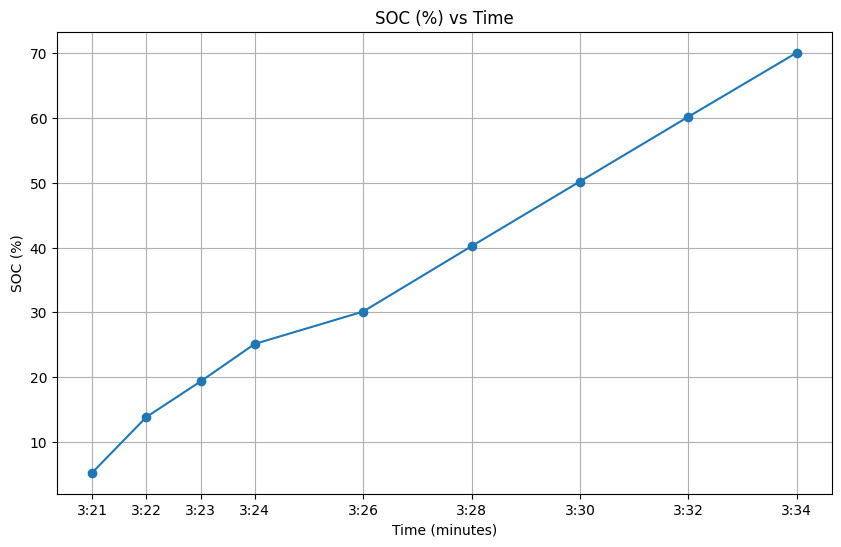

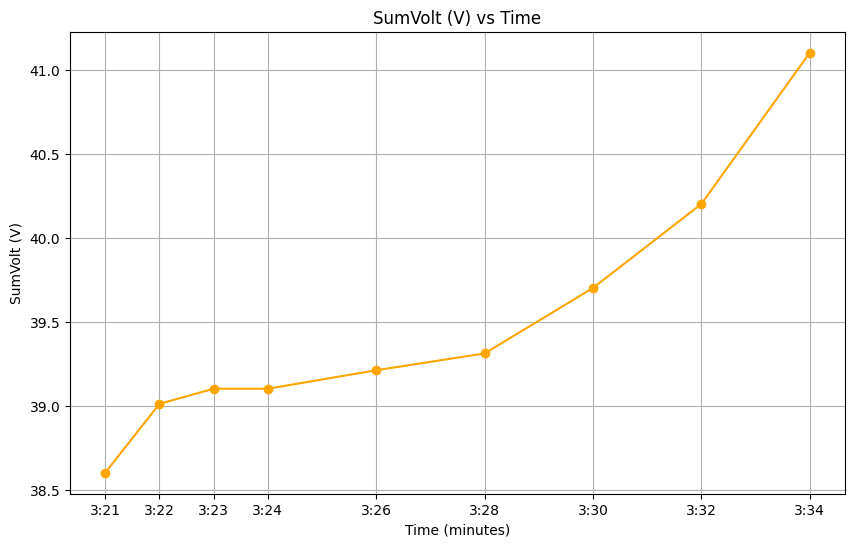

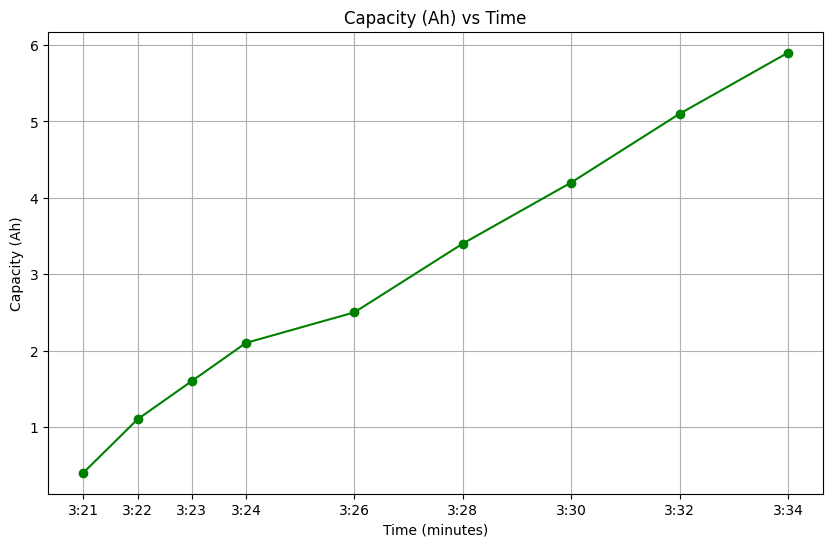

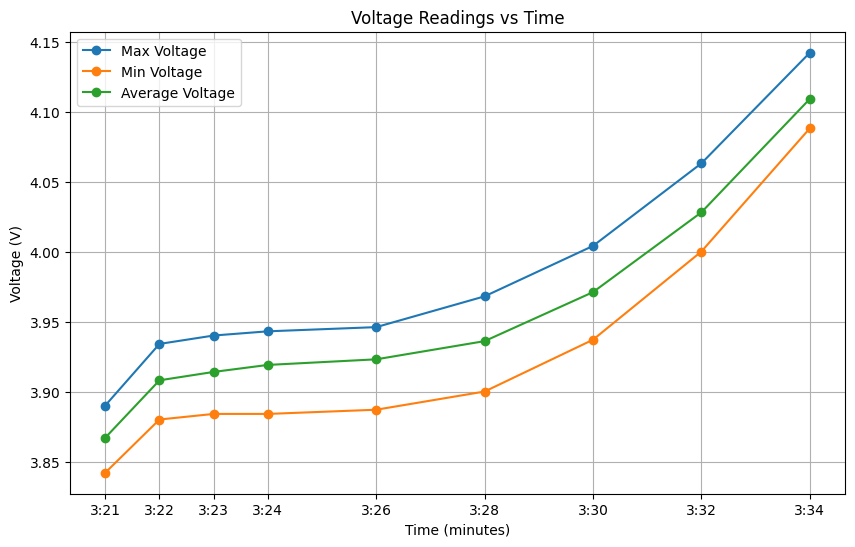

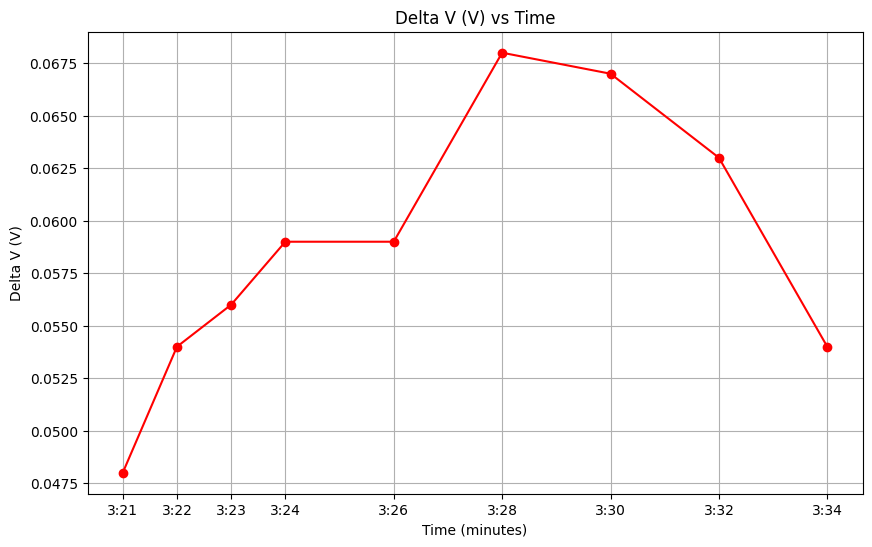

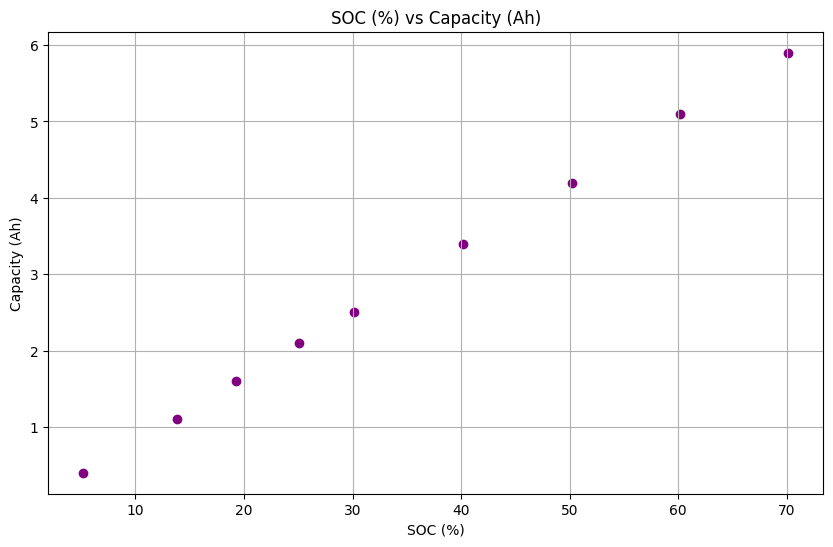

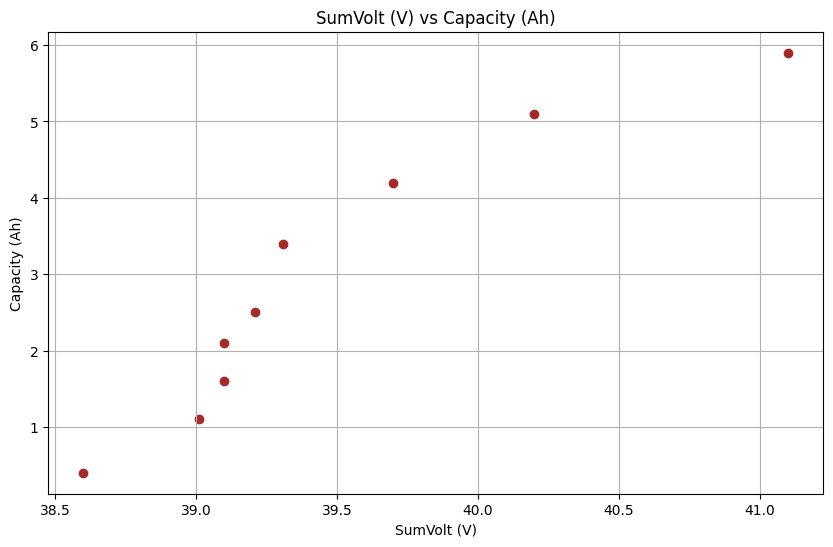

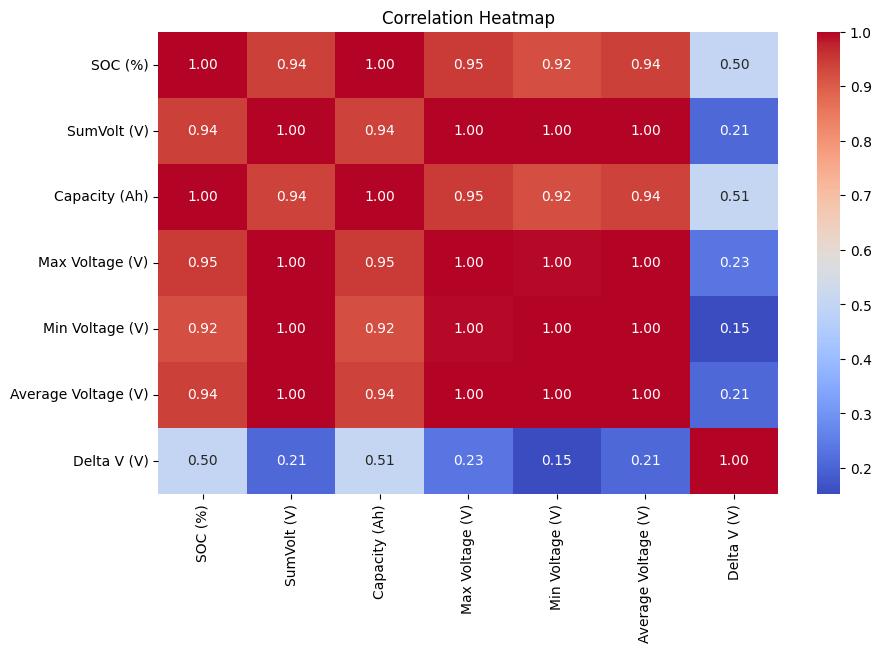

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame from your data
data = {
    "Filename": [
        "IMG_4983.PNG", "IMG_4985.PNG", "IMG_4987.PNG", "IMG_4990.PNG",
        "IMG_4992.PNG", "IMG_4994.PNG", "IMG_4996.PNG", "IMG_4998.PNG", "IMG_5001.PNG"
    ],
    "Timestamp": ["3:21", "3:22", "3:23", "3:24", "3:26", "3:28", "3:30", "3:32", "3:34"],
    "SOC (%)": [5.2, 13.8, 19.3, 25.1, 30.1, 40.2, 50.2, 60.2, 70.1],
    "SumVolt (V)": [38.6, 39.01, 39.1, 39.1, 39.21, 39.31, 39.7, 40.2, 41.1],
    "Current (A)": [25.4, 25.4, 25.4, 25.4, 25.4, 25.3, 25.3, 25.3, 25.3],
    "Capacity (Ah)": [0.4, 1.1, 1.6, 2.1, 2.5, 3.4, 4.2, 5.1, 5.9],
    "Max Voltage (V)": [3.890, 3.934, 3.940, 3.943, 3.946, 3.968, 4.004, 4.063, 4.142],
    "Min Voltage (V)": [3.842, 3.880, 3.884, 3.884, 3.887, 3.900, 3.937, 4.000, 4.088],
    "Average Voltage (V)": [3.867, 3.908, 3.914, 3.919, 3.923, 3.936, 3.971, 4.028, 4.109],
    "Delta V (V)": [0.048, 0.054, 0.056, 0.059, 0.059, 0.068, 0.067, 0.063, 0.054]
}

df = pd.DataFrame(data)

# Convert the Timestamp to minutes for easier numeric plotting.
def time_to_minutes(t):
    parts = t.split(":")
    return int(parts[0]) * 60 + int(parts[1])

df["Time_minutes"] = df["Timestamp"].apply(time_to_minutes)

# Set common figure size
plt.rcParams["figure.figsize"] = (10, 6)

# ----------------------------
# 1. SOC (%) vs Time
plt.figure()
plt.plot(df["Time_minutes"], df["SOC (%)"], marker='o', linestyle='-')
plt.title("SOC (%) vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("SOC (%)")
plt.xticks(df["Time_minutes"], df["Timestamp"])
plt.grid(True)
plt.show()

# ----------------------------
# 2. SumVolt (V) vs Time
plt.figure()
plt.plot(df["Time_minutes"], df["SumVolt (V)"], marker='o', linestyle='-', color='orange')
plt.title("SumVolt (V) vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("SumVolt (V)")
plt.xticks(df["Time_minutes"], df["Timestamp"])
plt.grid(True)
plt.show()

# ----------------------------
# 3. Capacity (Ah) vs Time
plt.figure()
plt.plot(df["Time_minutes"], df["Capacity (Ah)"], marker='o', linestyle='-', color='green')
plt.title("Capacity (Ah) vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("Capacity (Ah)")
plt.xticks(df["Time_minutes"], df["Timestamp"])
plt.grid(True)
plt.show()

# ----------------------------
# 4. Voltage Readings vs Time: Max, Min, Average Voltage
plt.figure()
plt.plot(df["Time_minutes"], df["Max Voltage (V)"], marker='o', linestyle='-', label="Max Voltage")
plt.plot(df["Time_minutes"], df["Min Voltage (V)"], marker='o', linestyle='-', label="Min Voltage")
plt.plot(df["Time_minutes"], df["Average Voltage (V)"], marker='o', linestyle='-', label="Average Voltage")
plt.title("Voltage Readings vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("Voltage (V)")
plt.xticks(df["Time_minutes"], df["Timestamp"])
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# 5. Delta V (V) vs Time
plt.figure()
plt.plot(df["Time_minutes"], df["Delta V (V)"], marker='o', linestyle='-', color='red')
plt.title("Delta V (V) vs Time")
plt.xlabel("Time (minutes)")
plt.ylabel("Delta V (V)")
plt.xticks(df["Time_minutes"], df["Timestamp"])
plt.grid(True)
plt.show()

# ----------------------------
# 6. Scatter Plot: SOC (%) vs Capacity (Ah)
plt.figure()
plt.scatter(df["SOC (%)"], df["Capacity (Ah)"], color='purple')
plt.title("SOC (%) vs Capacity (Ah)")
plt.xlabel("SOC (%)")
plt.ylabel("Capacity (Ah)")
plt.grid(True)
plt.show()

# ----------------------------
# 7. Scatter Plot: SumVolt (V) vs Capacity (Ah)
plt.figure()
plt.scatter(df["SumVolt (V)"], df["Capacity (Ah)"], color='brown')
plt.title("SumVolt (V) vs Capacity (Ah)")
plt.xlabel("SumVolt (V)")
plt.ylabel("Capacity (Ah)")
plt.grid(True)
plt.show()

# ----------------------------
# 8. Correlation Heatmap
cols_for_corr = ["SOC (%)", "SumVolt (V)", "Capacity (Ah)", "Max Voltage (V)", "Min Voltage (V)", "Average Voltage (V)", "Delta V (V)"]
corr = df[cols_for_corr].corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


The X axis indicates time in minutes but its actually hours:minutes

based on this chart can you create a linear equation to approximate the Ah capacity values for the SOC% above 70% upto 100%.?

Below is one straightforward way to derive a linear model for Capacity (Ah) above about 70% SOC by extrapolating from the upper portion of the available data. Since we only have data up to 70.1% SOC, we must extend (extrapolate) that trend to estimate the capacity between 70% and 100% SOC.

1. Select the Data Points to Model the High-SOC Range
To get a slope that represents the battery behavior near the higher state of charge, we can focus on the three data points above 50% SOC (so that we have enough points to form a regression line):

SOC (%)	Capacity (Ah)
50.2	4.2
60.2	5.1
70.1	5.9
(If you prefer to use the entire dataset, or just the last two points, you can do so. This example uses the last three points to capture the slope near the higher SOC range.)

2. Compute a Linear Regression
We want a line of the form:

Capacity
(
A
h
)

=

𝑚
×
SOC
(
%
)

+

𝑏
Capacity(Ah)=m×SOC(%)+b
where
𝑚
m is the slope and
𝑏
b is the intercept.

Let
{
𝑥
𝑖
}
{x
i
​
 } be SOC (%) and
{
𝑦
𝑖
}
{y
i
​
 } be Capacity (Ah).

Number of points:
𝑁
=
3
N=3.

Use the standard least-squares formulas for slope and intercept:

𝑚

=

𝑁
∑
(
𝑥
𝑖
𝑦
𝑖
)
−
(
∑
𝑥
𝑖
)
(
∑
𝑦
𝑖
)
𝑁
∑
(
𝑥
𝑖
2
)
−
(
∑
𝑥
𝑖
)
2
,
𝑏

=

𝑦
ˉ
−
𝑚

𝑥
ˉ
m=
N∑(x
i
2
​
 )−(∑x
i
​
 )
2

N∑(x
i
​
 y
i
​
 )−(∑x
i
​
 )(∑y
i
​
 )
​
 ,b=
y
ˉ
​
 −m
x
ˉ

where
𝑥
ˉ
=
1
𝑁
∑
𝑥
𝑖
,
𝑦
ˉ
=
1
𝑁
∑
𝑦
𝑖
.
x
ˉ
 =
N
1
​
 ∑x
i
​
 ,
y
ˉ
​
 =
N
1
​
 ∑y
i
​
 .

Example Calculation
Points
(
𝑥
1
,
𝑦
1
)
=
(
50.2
,

4.2
)
,


(
𝑥
2
,
𝑦
2
)
=
(
60.2
,

5.1
)
,


(
𝑥
3
,
𝑦
3
)
=
(
70.1
,

5.9
)
(x
1
​
 ,y
1
​
 )=(50.2,4.2),(x
2
​
 ,y
2
​
 )=(60.2,5.1),(x
3
​
 ,y
3
​
 )=(70.1,5.9)

Slope
(
𝑚
≈
0.0854
)
(m≈0.0854)

Intercept
(
𝑏
≈
−
0.07
)
(b≈−0.07)

Hence, the best-fit line (over those three points) is approximately:

Capacity
(
A
h
)

=

0.0854
×
SOC
(
%
)

−

0.07
Capacity(Ah)=0.0854×SOC(%)−0.07
​

(Rounding to 3 decimal places for the slope and 2 decimal places for the intercept is usually sufficient.)

3. Interpret and Extrapolate
Using this linear model for SOC > 70%:

At 70% SOC, the formula yields

0.0854
×
70
−
0.07
≈
5.9
0.0854×70−0.07≈5.9 Ah, which aligns with the measured data.

At 100% SOC, the formula predicts

0.0854
×
100
−
0.07
≈
8.47
0.0854×100−0.07≈8.47 Ah.

Because we do not have measured data beyond 70.1%, this line is purely an extrapolation. In real battery systems, the relationship between SOC and capacity often becomes nonlinear near full charge, so treat this as a rough estimate rather than a guaranteed value.

Final Linear Approximation (70% ≤ SOC ≤ 100%)
Capacity
(
A
h
)

≈

0.0854

×

SOC
(
%
)

−

0.07
Capacity(Ah)≈0.0854×SOC(%)−0.07
​

This provides a simple linear way to estimate capacity up to 100% SOC, based on the higher-SOC portion of the data you have collected.

So, AI calculated 8.47Ah at 100% SOC which is pretty close to reality

25.55 A /  15 minutes, what is the battery Ah


ChatGPT said:
Reasoned for a couple of seconds
To find the ampere-hours (Ah) corresponding to a 25.55 A current over 15 minutes, do the following:

Convert 15 minutes to hours:

15

minutes
=
0.25

hours
15minutes=0.25hours
Multiply current by time:

25.55

A
×
0.25

h
=
6.388

Ah
25.55A×0.25h=6.388Ah
Therefore, the battery receives approximately 6.39 Ah over that 15‑minute period.






You said:
what % is 6.39 of 8.45


ChatGPT said:
Reasoned for 4 seconds
To find what percentage 6.39 is of 8.45, you can use the formula:

Percentage
=
6.39
8.45
×
100
%
Percentage=
8.45
6.39
​
 ×100%
Performing the calculation:

6.39
8.45
≈
0.756
⇒
0.756
×
100
%
≈
75.6
%
8.45
6.39
​
 ≈0.756⇒0.756×100%≈75.6%
So, 6.39 is about 75.6% of 8.45.






You said:
assume a 16 day resting period for the battery, and it has a high parasitic loss from the the smart bms system and it drew the battery down taking out 6.39Ah.  Assume a 37V is the average voltage.  what is the power discharge current.


ChatGPT said:
Reasoned for 10 seconds
To estimate the average discharge current over 16 days given a loss of 6.39 Ah, we first convert the time period into hours:

Total hours
=
16
 days
×
24
 hours/day
=
384
 hours
Total hours=16 days×24 hours/day=384 hours
Then, the average current drawn is:

𝐼
avg
=
6.39
 Ah
384
 h
≈
0.01664
 A
(
or
16.6
 mA
)
I
avg
​
 =
384 h
6.39 Ah
​
 ≈0.01664 A(or 16.6 mA)
Since the average voltage is assumed to be 37 V, the corresponding power is:

𝑃
=
𝑉
×
𝐼
=
37
 V
×
0.01664
 A
≈
0.616
 W
P=V×I=37 V×0.01664 A≈0.616 W
Thus, the battery experienced an average parasitic discharge current of about 16.6 mA, which corresponds to roughly 0.62 W of power loss over the 16‑day resting period.